In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',None);
pd.set_option('display.max_columns',None)
train=pd.concat([pd.read_csv('/kaggle/input/datasets/shaadahmad51/aresole/SDNFlow_Dataset_Normal.csv'),pd.read_csv('/kaggle/input/datasets/shaadahmad51/aresole/SDNFlow_Dataset_attack.csv')])
train.head()
train=train.drop(columns=['flow_ID','eth_type','ipv4_src','ipv4_dst','ip_proto','src_port','dst_port','TnBPDstIP','TnBPSrcIP','TnPPDstIP','TnPPSrcIP','TnPPerDport','Tn_FlowsPDstIP','Tn_FlowsPSrcIP','Attack'])
train.head()
tester=pd.read_csv('/kaggle/input/datasets/shaadahmad51/aresole/modified_concatenated_InSDN_DatasetCSV.csv')
tester.head()

,Flow ID,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.3.130-200.175.2.130-38694-4444-6,10/1/2020 5:02,269709,4,5,48,23,30,0,12.0,14.696938,23,0,4.600000,10.285913,263.246684,33.369298,33713.625000,90272.549880,257068,14,260808,86936.0,149854.765700,259973,104,269709,67427.250000,126912.740800,257785,2956,0,0,0,0,128,176,14.830799,18.538499,0,30,7.100000,11.779926,138.766667,0,1,0,0,0,0,0,0,1,7.888889,12.0,4.600000,0,0,0,0,0,0,4,48,5,23,-1,64,2,0,0.0,0.0,0,0,0.0,0.0,0,0,U2R
1,192.168.3.130-200.175.2.130-38693-4444-6,10/1/2020 5:02,268599,2,3,0,23,0,0,0.0,0.000000,23,0,7.666667,13.279056,85.629507,18.615110,67149.750000,132430.553600,265786,11,265811,265811.0,0.000000,265811,265811,268574,134287.000000,185983.225600,265797,2777,0,0,0,0,64,112,7.446044,11.169066,0,23,3.833333,9.389711,88.166667,0,1,0,0,0,0,0,0,1,4.600000,0.0,7.666667,0,0,0,0,0,0,2,0,3,23,-1,64,0,0,0.0,0.0,0,0,0.0,0.0,0,0,U2R
2,192.168.3.130-200.175.2.130-3632-33747-6,10/1/2020 5:02,22194,5,5,53,30,30,0,10.6,14.724130,30,0,6.000000,13.416408,3739.749482,450.572227,2466.000000,2951.053583,8063,3,17518,4379.5,6184.320254,13537,3,15128,3782.000000,3420.925898,8063,42,0,0,0,0,160,176,225.286113,225.286113,0,30,7.545455,13.048859,170.272727,0,1,0,0,0,0,0,0,1,8.300000,10.6,6.000000,0,0,0,0,0,0,5,53,5,30,-1,215,2,0,0.0,0.0,0,0,0.0,0.0,0,0,U2R
3,192.168.3.130-200.175.2.130-8180-38745-6,10/1/2020 1:39,9556,4,4,30,30,30,0,7.5,15.000000,30,0,7.500000,15.000000,6278.777731,837.170364,1365.142857,1447.714225,4022,13,5511,1837.0,1441.824885,3380,524,5588,1862.666667,2386.259067,4559,23,0,0,0,0,128,144,418.585182,418.585182,0,30,6.666667,13.228757,175.000000,0,1,0,0,0,0,0,0,1,7.500000,7.5,7.500000,0,0,0,0,0,0,4,30,4,30,-1,215,1,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA
4,192.168.3.130-200.175.2.130-8180-37217-6,10/1/2020 1:39,8782,4,4,30,30,30,0,7.5,15.000000,30,0,7.500000,15.000000,6832.156684,910.954225,1254.571429,1607.096435,4049,8,4725,1575.0,2277.042160,4204,226,5618,1872.666667,2191.816674,4287,8,0,0,0,0,128,144,455.477112,455.477112,0,30,6.666667,13.228757,175.000000,0,1,0,0,0,0,0,0,1,7.500000,7.5,7.500000,0,0,0,0,0,0,4,30,4,30,-1,215,1,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA


In [2]:
tester = tester.drop(columns=[
    'Pkt Len Min',
    'Pkt Len Max',
    'Pkt Len Mean',
    'Pkt Len Std',
    'Pkt Len Var',
    'FIN Flag Cnt',
    'SYN Flag Cnt',
    'RST Flag Cnt',
    'PSH Flag Cnt',
    'ACK Flag Cnt',
    'URG Flag Cnt',
    'CWE Flag Count',
    'ECE Flag Cnt',
    'Down/Up Ratio'
])

In [3]:
tester = tester.drop(columns=[
    'Flow IAT Mean',
    'Flow IAT Std',
    'Flow IAT Max',
    'Flow IAT Min',
    'Fwd IAT Tot',
    'Fwd IAT Mean',
    'Fwd IAT Std',
    'Fwd IAT Max',
    'Fwd IAT Min',
    'Bwd IAT Tot',
    'Bwd IAT Mean',
    'Bwd IAT Std',
    'Bwd IAT Max',
    'Bwd IAT Min',
    'Fwd PSH Flags',
    'Bwd PSH Flags',
    'Fwd URG Flags',
    'Bwd URG Flags',
    'Fwd Header Len',
    'Bwd Header Len'
])

In [4]:
tester = tester.drop(columns=[
    'Fwd Pkt Len Max',
    'Fwd Pkt Len Min',
    'Fwd Pkt Len Mean',
    'Fwd Pkt Len Std',
    'Bwd Pkt Len Max',
    'Bwd Pkt Len Min',
    'Bwd Pkt Len Mean',
    'Bwd Pkt Len Std'
])

In [5]:
tester=tester.drop(columns=['Flow ID','Timestamp','Flow Duration'])

tester['Tot Fwd Pkts']=tester['Tot Fwd Pkts']+tester['Tot Bwd Pkts']
tester=tester.rename(columns={'Tot Fwd Pkts':'tot_pkts'})

tester['TotLen Fwd Pkts']=tester['TotLen Fwd Pkts']+tester['TotLen Bwd Pkts']
tester=tester.rename(columns={'TotLen Fwd Pkts':'tot_len_pkts'})

tester=tester.drop(columns=['Tot Bwd Pkts','TotLen Bwd Pkts','Fwd Pkts/s','Bwd Pkts/s'])

tester=tester.rename(columns={'Flow Byts/s':'flow_byts_s','Flow Pkts/s':'flow_pkts_s','Pkt Size Avg':'pkt_size_average', 'Active Mean': 'active_mean',
    'Active Std': 'active_std',
    'Active Max': 'active_max',
    'Active Min': 'active_min',
    'Idle Mean': 'idle_mean',
    'Idle Std': 'idle_std',
    'Idle Max': 'idle_max',
    'Idle Min': 'idle_min'
})

In [6]:
train = train.drop(columns=[
    'fwd_header_len',
    'Byts_max_interval_2s',
    'Byts_min_interval_2s',
    'Byts_mean_interval_2s',
    'Byts_std_interval_2s',
    'Pkts_max_interval_2s',
    'Pkts_mean_interval_2s',
    'Pkts_min_interval_2s',
    'Pkts_std_interval_2s'
])

In [7]:
train=train.drop(columns='flow_duration')
train.head()
y=train['Category']
train.head()
X=train
y.head()
y=y.str.upper()
y.head()
y.value_counts()
y=y[~y.isin(['STREAMING','SSH','ICMP','FTP','NTP'])]
y.value_counts()
tester['Label'].value_counts()
tester['Label']=tester['Label'].str.upper()
tester['Label'].value_counts()
tester['Label']=tester['Label'].str.strip()
tester['Label'].value_counts()

Label
DDOS          121942
PROBE          98129
NORMAL         68424
DOS            53616
BFA             1405
WEB-ATTACK       192
BOTNET           164
U2R               17
Name: count, dtype: int64

In [8]:
y=y.replace({
    'HTTP':'NORMAL',
    'PASSWORD-GUESSING':'BFA',
    'DNS':'BOTNET'
})
y.value_counts()
y.isnull().sum()
X.isnull().sum()
from sklearn.model_selection import train_test_split
X.shape
y.shape
y.head()
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
X.shape
y.shape

(659789,)

In [9]:
train['Category'].value_counts()
safe_train=train
train['Category']=train['Category'].str.strip()
train['Category']=train['Category'].str.upper()
train['Category'].value_counts()
train=train[~train['Category'].isin(['STREAMING','SSH','ICMP','FTP','NTP'])]
train['Category'].value_counts()
y=train['Category']
y=le.fit_transform(y)
df=pd.DataFrame(y)
df.value_counts()

0
3    164974
5    151456
2    123807
0     74644
4     67288
1     53551
6     17787
7      6282
Name: count, dtype: int64

In [10]:
X=train.drop(columns='Category')
X.shape
y.shape
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score
)

from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [14]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(np.unique(y_train_enc))

print("Classes:", num_classes)
print(Counter(y_train_enc))

Classes: 8
Counter({np.int64(3): 131979, np.int64(5): 121165, np.int64(2): 99045, np.int64(0): 59715, np.int64(4): 53830, np.int64(1): 42841, np.int64(6): 14230, np.int64(7): 5026})


In [15]:
latent_dim = 100
input_dim = X_train.shape[1]


class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, input_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [16]:
generator_losses = []
discriminator_losses = []

epochs = 500
batch_size = 128
lr = 0.0002

counter = Counter(y_train_enc)
majority_count = max(counter.values())

synthetic_X = []
synthetic_y = []

for cls in range(num_classes):

    cls_idx = np.where(y_train_enc == cls)[0]

    if len(cls_idx) >= majority_count:
        continue

    X_cls = X_train[cls_idx]

    X_tensor = torch.tensor(
        X_cls,
        dtype=torch.float32
    ).to(device)

    G = Generator().to(device)
    D = Discriminator().to(device)

    criterion = nn.BCELoss()

    g_optimizer = torch.optim.Adam(
        G.parameters(),
        lr=lr
    )

    d_optimizer = torch.optim.Adam(
        D.parameters(),
        lr=lr
    )

    dataset_size = len(X_tensor)

    for epoch in range(epochs):

        idx = torch.randint(
            0,
            dataset_size,
            (batch_size,)
        )

        real_data = X_tensor[idx]

        real_labels = torch.ones(
            (batch_size,1),
            device=device
        )

        fake_labels = torch.zeros(
            (batch_size,1),
            device=device
        )

        # Train D
        z = torch.randn(
            batch_size,
            latent_dim,
            device=device
        )

        fake_data = G(z)

        d_real = D(real_data)
        d_fake = D(fake_data.detach())

        d_loss_real = criterion(
            d_real,
            real_labels
        )

        d_loss_fake = criterion(
            d_fake,
            fake_labels
        )

        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train G
        z = torch.randn(
            batch_size,
            latent_dim,
            device=device
        )

        fake_data = G(z)

        g_loss = criterion(
            D(fake_data),
            real_labels
        )

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        generator_losses.append(g_loss.item())
        discriminator_losses.append(d_loss.item())

    needed = majority_count - len(cls_idx)

    z = torch.randn(
        needed,
        latent_dim,
        device=device
    )

    generated = (
        G(z)
        .detach()
        .cpu()
        .numpy()
    )

    synthetic_X.append(generated)
    synthetic_y.append(
        np.full(needed, cls)
    )

    print(
        f"Class {cls} -> Generated {needed} samples"
    )

Class 0 -> Generated 72264 samples
Class 1 -> Generated 89138 samples
Class 2 -> Generated 32934 samples
Class 4 -> Generated 78149 samples
Class 5 -> Generated 10814 samples
Class 6 -> Generated 117749 samples
Class 7 -> Generated 126953 samples


In [17]:
if len(synthetic_X) > 0:

    synthetic_X = np.vstack(synthetic_X)
    synthetic_y = np.concatenate(synthetic_y)

    X_balanced = np.vstack([
        X_train,
        synthetic_X
    ])

    y_balanced = np.concatenate([
        y_train_enc,
        synthetic_y
    ])

else:
    X_balanced = X_train
    y_balanced = y_train_enc

print("Balanced Shape:", X_balanced.shape)
print(Counter(y_balanced))

Balanced Shape: (1055832, 13)
Counter({np.int64(1): 131979, np.int64(2): 131979, np.int64(5): 131979, np.int64(3): 131979, np.int64(4): 131979, np.int64(0): 131979, np.int64(6): 131979, np.int64(7): 131979})


In [18]:
eval_set = [
    (X_balanced, y_balanced),
    (X_test, y_test_enc)
]

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softprob",
    num_class=num_classes,

    tree_method="hist",
    device="cuda",

    eval_metric=[
        "mlogloss",
        "merror"
    ],

    random_state=42
)

xgb_model.fit(
    X_balanced,
    y_balanced,
    eval_set=eval_set,
    verbose=50
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:46:23] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:46:23] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:1.95429	validation_0-merror:0.21245	validation_1-mlogloss:2.00281	validation_1-merror:0.37838
[50]	validation_0-mlogloss:0.61904	validation_0-merror:0.17587	validation_1-mlogloss:1.02945	validation_1-merror:0.32773
[100]	validation_0-mlogloss:0.49222	validation_0-merror:0.16773	validation_1-mlogloss:0.91317	validation_1-merror:0.31625
[150]	validation_0-mlogloss:0.45969	validation_0-merror:0.16158	validation_1-mlogloss:0.87359	validation_1-merror:0.30705
[200]	validation_0-mlogloss:0.44459	validation_0-merror:0.15808	validation_1-mlogloss:0.85259	validation_1-merror:0.30231
[250]	validation_0-mlogloss:0.43251	validation_0-merror:0.15436	validation_1-mlogloss:0.83413	validation_1-merror:0.29682
[300]	validation_0-mlogloss:0.42396	validation_0-merror:0.15165	validation_1-mlogloss:0.82173	validation_1-merror:0.29329
[350]	validation_0-mlogloss:0.41727	validation_0-merror:0.14936	validation_1-mlogloss:0.81228	validation_1-merror:0.29024
[400]	validation_0-mlogloss

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['mlogloss', 'merror'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=8, ...)

In [19]:
preds = xgb_model.predict(X_test)

print(
    classification_report(
        y_test_enc,
        preds,
        target_names=le.classes_.astype(str)
    )
)

acc = accuracy_score(
    y_test_enc,
    preds
)

f1 = f1_score(
    y_test_enc,
    preds,
    average="weighted"
)

print("Accuracy :", acc)
print("F1 Score :", f1)

              precision    recall  f1-score   support

           0       0.95      0.27      0.42     14929
           1       0.86      0.23      0.36     10710
           2       0.92      0.90      0.91     24762
           3       0.90      0.68      0.77     32995
           4       0.93      0.77      0.84     13458
           5       0.48      0.96      0.64     30291
           6       0.88      0.73      0.80      3557
           7       0.87      0.79      0.83      1256

    accuracy                           0.71    131958
   macro avg       0.85      0.67      0.70    131958
weighted avg       0.81      0.71      0.70    131958

Accuracy : 0.7143636611649161
F1 Score : 0.7037525553848256


In [20]:
results = xgb_model.evals_result()

train_loss = results["validation_0"]["mlogloss"]
test_loss = results["validation_1"]["mlogloss"]

train_error = results["validation_0"]["merror"]
test_error = results["validation_1"]["merror"]

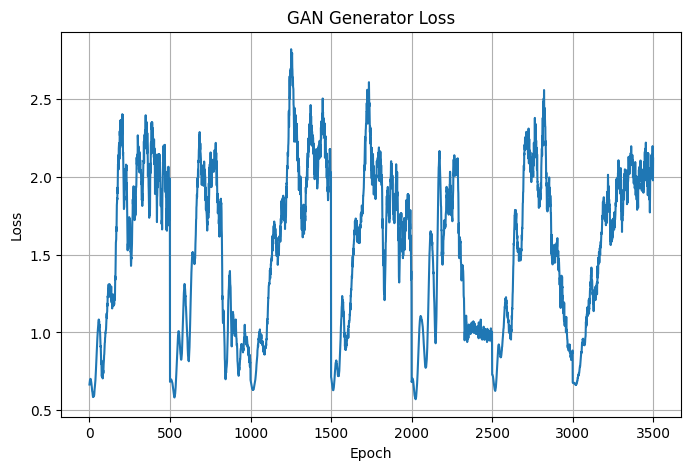

In [21]:
plt.figure(figsize=(8,5))

plt.plot(generator_losses)

plt.title("GAN Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

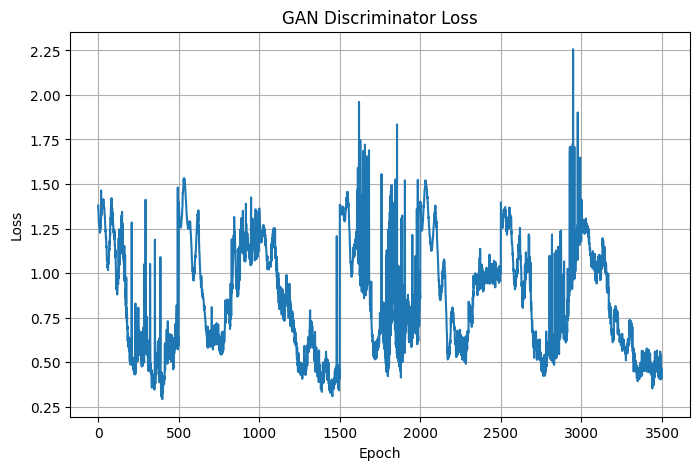

In [22]:
plt.figure(figsize=(8,5))

plt.plot(discriminator_losses)

plt.title("GAN Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

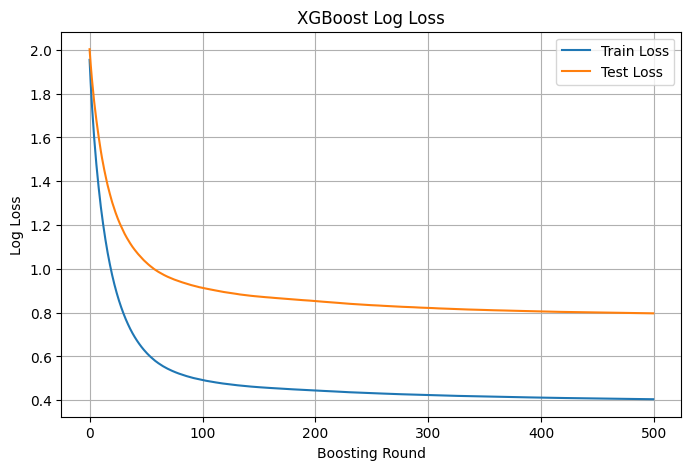

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    train_loss,
    label="Train Loss"
)

plt.plot(
    test_loss,
    label="Test Loss"
)

plt.title("XGBoost Log Loss")

plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")

plt.legend()
plt.grid(True)

plt.show()

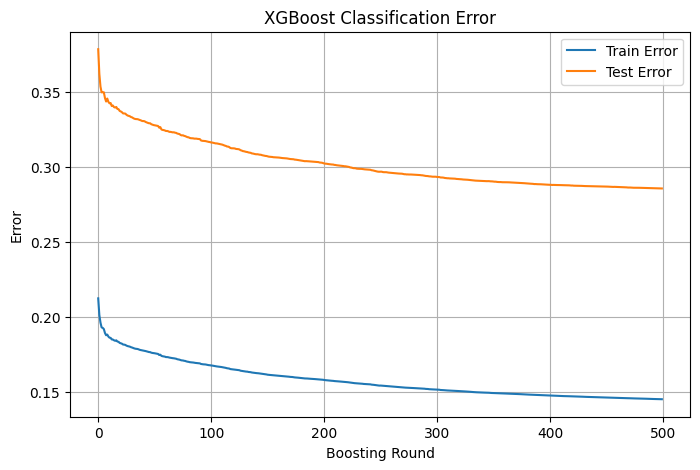

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    train_error,
    label="Train Error"
)

plt.plot(
    test_error,
    label="Test Error"
)

plt.title("XGBoost Classification Error")

plt.xlabel("Boosting Round")
plt.ylabel("Error")

plt.legend()
plt.grid(True)

plt.show()